# DAY 4 - Baseline Model + MLflow Setup

## What we do today:
1. Split data into train and test sets
2. Build a simple baseline model
3. Set up MLflow to track all experiments
4. Record the baseline score
5. Every model in Day 5 must beat this score

Run each cell one by one using Shift+Enter

## CELL 1 - Import Libraries
Loading all tools needed for modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

os.makedirs('docs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print('All libraries loaded!')
print()
print('Key libraries:')
print('  pandas      - data handling')
print('  sklearn     - machine learning models and metrics')
print('  mlflow      - experiment tracking (saves all results automatically)')
print('  matplotlib  - charts')

All libraries loaded!

Key libraries:
  pandas      - data handling
  sklearn     - machine learning models and metrics
  mlflow      - experiment tracking (saves all results automatically)
  matplotlib  - charts


## CELL 2 - Load the Clean Dataset
We load from data/processed/ which we created in Day 3.
This has all our fixed data and new features.

In [3]:
df = pd.read_csv('data/processed/churn_clean.csv')

print(f'Clean data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print()
print('Churn distribution:')
churn_counts = df['Churn'].value_counts()
print(f'  Stayed  (0): {churn_counts[0]:,} customers ({churn_counts[0]/len(df)*100:.1f}%)')
print(f'  Churned (1): {churn_counts[1]:,} customers ({churn_counts[1]/len(df)*100:.1f}%)')
print()
print('All columns:')
print(df.columns.tolist())

Clean data loaded: 7043 rows, 27 columns

Churn distribution:
  Stayed  (0): 5,174 customers (73.5%)
  Churned (1): 1,869 customers (26.5%)

All columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'is_new_customer', 'is_loyal_customer', 'charges_per_month', 'num_services', 'has_support', 'is_high_value', 'contract_risk']


## CELL 3 - Separate Features and Target
X = all the input columns (features) the model learns from
y = the answer column (Churn 0 or 1) the model tries to predict

Think of X as the question and y as the answer.

In [4]:
# X = everything except Churn
X = df.drop('Churn', axis=1)

# y = just the Churn column
y = df['Churn']

print('X (features) shape:', X.shape)
print('y (target) shape  :', y.shape)
print()
print(f'We have {X.shape[1]} features to train on:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')

X (features) shape: (7043, 26)
y (target) shape  : (7043,)

We have 26 features to train on:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. InternetService
   9. OnlineSecurity
  10. OnlineBackup
  11. DeviceProtection
  12. TechSupport
  13. StreamingTV
  14. StreamingMovies
  15. Contract
  16. PaperlessBilling
  17. PaymentMethod
  18. MonthlyCharges
  19. TotalCharges
  20. is_new_customer
  21. is_loyal_customer
  22. charges_per_month
  23. num_services
  24. has_support
  25. is_high_value
  26. contract_risk


## CELL 4 - Split Data into Train and Test

VERY IMPORTANT: We use the FIRST 80% of data to train.
We use the LAST 20% of data to test.

WHY NOT RANDOM SPLIT?
In real life, we train on past data and predict future data.
Random split would leak future information into training.
This is called DATA LEAKAGE and is a fatal mistake!

Think of it like studying for an exam:
You study old questions (train) and get tested on new questions (test).
You would never study the exact exam questions beforehand.

In [5]:
# Calculate split point
total_rows = len(df)
split_point = int(total_rows * 0.80)

# Split based on position (time-based style)
X_train = X.iloc[:split_point]   # First 80%
X_test  = X.iloc[split_point:]   # Last 20%
y_train = y.iloc[:split_point]
y_test  = y.iloc[split_point:]

print('=== DATA SPLIT RESULTS ===')
print()
print(f'Total data    : {total_rows:,} customers')
print(f'Split point   : row {split_point:,}')
print()
print(f'Training set  : {len(X_train):,} customers (80%) <- model LEARNS from this')
print(f'Test set      : {len(X_test):,}  customers (20%) <- model TESTED on this')
print()
print('Churn rate in each set:')
print(f'  Train churn rate: {y_train.mean()*100:.1f}%')
print(f'  Test  churn rate: {y_test.mean()*100:.1f}%')
print()
print('Good! Both sets have similar churn rates.')
print('This means the split is representative.')

=== DATA SPLIT RESULTS ===

Total data    : 7,043 customers
Split point   : row 5,634

Training set  : 5,634 customers (80%) <- model LEARNS from this
Test set      : 1,409  customers (20%) <- model TESTED on this

Churn rate in each set:
  Train churn rate: 26.4%
  Test  churn rate: 27.0%

Good! Both sets have similar churn rates.
This means the split is representative.


## CELL 5 - Understand Our Metrics
Before building any model, understand what we are measuring.

For churn prediction, RECALL is most important.
Recall = out of all real churners, how many did we catch?

WHY RECALL?
Missing a churner (false negative) = losing a customer = losing money
False alarm (false positive) = sending unnecessary offer = small cost
Missing real churners is much worse than false alarms.

In [6]:
print('=== UNDERSTANDING OUR METRICS ===')
print()
print('ACCURACY  : Overall % of correct predictions')
print('            Problem: Misleading for imbalanced data!')
print('            If model predicts No for everyone -> 73% accuracy but useless')
print()
print('PRECISION : Of all customers we flagged as churning, how many actually churned?')
print('            High precision = fewer false alarms')
print()
print('RECALL    : Of all customers who actually churned, how many did we catch?')
print('            High recall = catch more real churners')
print('            *** THIS IS OUR PRIMARY METRIC ***')
print()
print('F1 SCORE  : Balance between Precision and Recall')
print('            Good overall measure')
print()
print('AUC ROC   : How well model separates churners from non-churners')
print('            1.0 = perfect, 0.5 = random guessing')
print()
print('OUR GOAL: Recall > 0.75 (catch 75%+ of all churners)')

=== UNDERSTANDING OUR METRICS ===

ACCURACY  : Overall % of correct predictions
            Problem: Misleading for imbalanced data!
            If model predicts No for everyone -> 73% accuracy but useless

PRECISION : Of all customers we flagged as churning, how many actually churned?
            High precision = fewer false alarms

RECALL    : Of all customers who actually churned, how many did we catch?
            High recall = catch more real churners
            *** THIS IS OUR PRIMARY METRIC ***

F1 SCORE  : Balance between Precision and Recall
            Good overall measure

AUC ROC   : How well model separates churners from non-churners
            1.0 = perfect, 0.5 = random guessing

OUR GOAL: Recall > 0.75 (catch 75%+ of all churners)


## CELL 6 - Set Up MLflow Experiment Tracking
MLflow is like a diary for your experiments.
Every model you run gets saved automatically with all its scores.
You can compare all experiments in one place.

In [7]:
# Name our experiment
EXPERIMENT_NAME = 'churn-prediction'

# Set up mlflow
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow experiment created: {EXPERIMENT_NAME}')
print()
print('What MLflow saves for each experiment:')
print('  - Model name')
print('  - All metrics (recall, f1, auc, etc)')
print('  - All parameters used')
print('  - The actual model file')
print()
print('After running models, open MLflow UI:')
print('  In terminal type: mlflow ui')
print('  Open browser: http://localhost:5000')
print('  You will see all experiments with charts!')

# Helper function to calculate and print all metrics
def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else 0.5

    print(f'--- {model_name} ---')
    print(f'  Accuracy  : {acc:.3f} ({acc*100:.1f}%)')
    print(f'  Precision : {prec:.3f}')
    print(f'  Recall    : {rec:.3f}  <- most important!')
    print(f'  F1 Score  : {f1:.3f}')
    print(f'  AUC ROC   : {auc:.3f}')
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

print()
print('Helper function created. Ready to run models!')

2026/03/11 09:39:15 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


MLflow experiment created: churn-prediction

What MLflow saves for each experiment:
  - Model name
  - All metrics (recall, f1, auc, etc)
  - All parameters used
  - The actual model file

After running models, open MLflow UI:
  In terminal type: mlflow ui
  Open browser: http://localhost:5000
  You will see all experiments with charts!

Helper function created. Ready to run models!


## CELL 7 - Baseline Model 1: Always Predict No (Dumbest Model)
This model predicts NO CHURN for every single customer.
It never catches any churner.
But it gets 73% accuracy because 73% of customers actually stayed!

This shows why accuracy alone is MISLEADING.

In [8]:
with mlflow.start_run(run_name='Baseline_AlwaysNo'):

    # Model that always predicts the most common class (No)
    dummy = DummyClassifier(strategy='most_frequent', random_state=42)
    dummy.fit(X_train, y_train)
    y_pred = dummy.predict(X_test)
    y_prob = dummy.predict_proba(X_test)[:, 1]

    metrics = evaluate_model('Always Predict No', y_test, y_pred, y_prob)

    # Save to MLflow
    mlflow.log_metrics(metrics)
    mlflow.log_param('model_type', 'DummyClassifier')
    mlflow.log_param('strategy', 'most_frequent')

print()
print('WHAT THIS MEANS:')
print('  Recall = 0.000 means it caught ZERO churners')
print('  Even though accuracy looks okay at 73%')
print('  This model is completely useless for business!')
print()
print('Our real models MUST have Recall > 0')

--- Always Predict No ---
  Accuracy  : 0.730 (73.0%)
  Precision : 0.000
  Recall    : 0.000  <- most important!
  F1 Score  : 0.000
  AUC ROC   : 0.500

WHAT THIS MEANS:
  Recall = 0.000 means it caught ZERO churners
  Even though accuracy looks okay at 73%
  This model is completely useless for business!

Our real models MUST have Recall > 0


## CELL 8 - Baseline Model 2: Simple Rule Based
Simple business rule: If customer has month-to-month contract AND tenure < 12 months, predict churn.
No ML involved - just common sense logic.
Our ML model must beat even this simple rule.

In [9]:
with mlflow.start_run(run_name='Baseline_SimpleRule'):

    # Simple rule: high contract risk AND new customer = predict churn
    # contract_risk=2 means month-to-month
    rule_pred = ((X_test['contract_risk'] == 2) &
                 (X_test['is_new_customer'] == 1)).astype(int)

    metrics = evaluate_model('Simple Business Rule', y_test, rule_pred)

    mlflow.log_metrics(metrics)
    mlflow.log_param('model_type', 'RuleBasedClassifier')
    mlflow.log_param('rule', 'contract_risk==2 AND is_new_customer==1')

print()
print('WHAT THIS MEANS:')
print('  This is what a business might do without any ML')
print('  Just flagging new month-to-month customers as risky')
print('  Our ML model should find much more nuanced patterns!')

--- Simple Business Rule ---
  Accuracy  : 0.762 (76.2%)
  Precision : 0.579
  Recall    : 0.441  <- most important!
  F1 Score  : 0.501
  AUC ROC   : 0.500

WHAT THIS MEANS:
  This is what a business might do without any ML
  Just flagging new month-to-month customers as risky
  Our ML model should find much more nuanced patterns!


## CELL 9 - Baseline Model 3: Logistic Regression (Simple ML)
Logistic Regression is the simplest ML model.
It draws a straight line to separate churners from non-churners.
Easy to explain, fast to train, good starting point.

class_weight=balanced means: pay more attention to churners
because they are the minority (only 27% of data)

In [10]:
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs scaled features
# Scaling: converts all numbers to same range (0 to 1)
# Without scaling: tenure (0-72) dominates MonthlyCharges (0-120)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

with mlflow.start_run(run_name='Baseline_LogisticRegression'):

    lr = LogisticRegression(
        class_weight='balanced',  # handle class imbalance
        max_iter=1000,            # enough iterations to converge
        random_state=42           # reproducible results
    )
    lr.fit(X_train_scaled, y_train)

    y_pred = lr.predict(X_test_scaled)
    y_prob = lr.predict_proba(X_test_scaled)[:, 1]

    metrics = evaluate_model('Logistic Regression', y_test, y_pred, y_prob)

    mlflow.log_metrics(metrics)
    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.sklearn.log_model(lr, 'logistic_regression_model')

print()
print('This is our true baseline!')
print('Random Forest and XGBoost in Day 5 must beat this recall score.')

2026/03/11 09:40:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 09:40:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


--- Logistic Regression ---
  Accuracy  : 0.746 (74.6%)
  Precision : 0.521
  Recall    : 0.759  <- most important!
  F1 Score  : 0.618
  AUC ROC   : 0.844

This is our true baseline!
Random Forest and XGBoost in Day 5 must beat this recall score.


## CELL 10 - Confusion Matrix Explained
A confusion matrix shows exactly what the model got right and wrong.
This is very important to understand and explain in interviews.

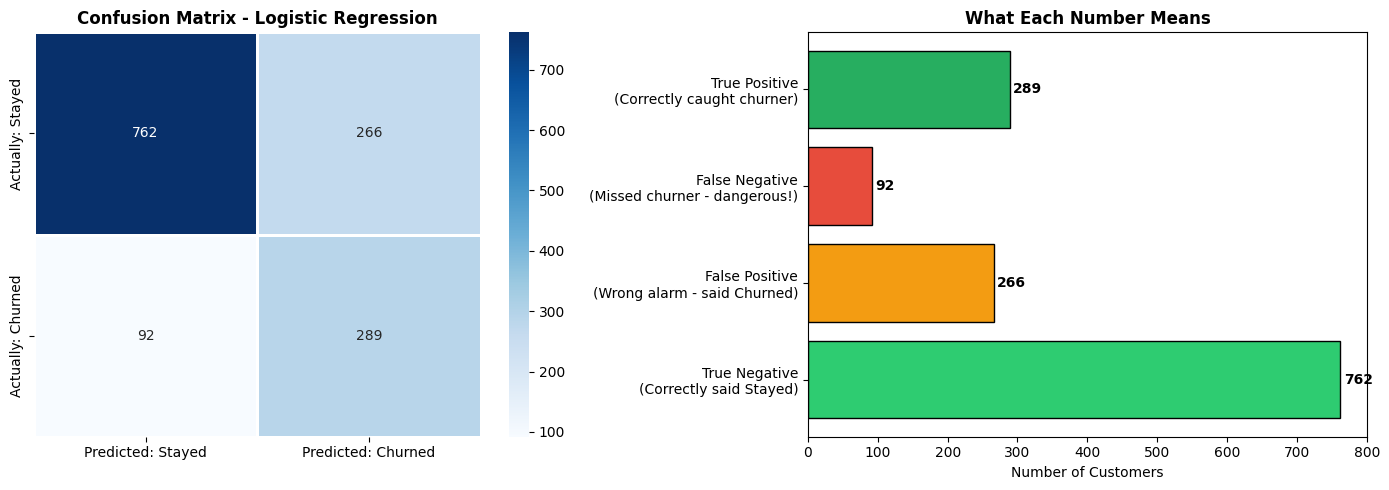

=== CONFUSION MATRIX EXPLAINED ===

  True Negative  (TN): 762 - Said stayed, actually stayed - CORRECT
  False Positive (FP): 266 - Said churned, actually stayed - False alarm
  False Negative (FN): 92 - Said stayed, actually churned - DANGEROUS!
  True Positive  (TP): 289 - Said churned, actually churned - CORRECT

  We caught 289 out of 381 real churners
  Recall = 289/381 = 0.76

GOAL: Minimize False Negatives (missed churners = lost revenue!)


In [11]:
# Get predictions from Logistic Regression
y_pred_lr = lr.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actually: Stayed', 'Actually: Churned'],
            ax=axes[0], linewidths=2)
axes[0].set_title('Confusion Matrix - Logistic Regression', fontweight='bold')

# Explanation bars
tn, fp, fn, tp = cm.ravel()
categories = ['True Negative\n(Correctly said Stayed)',
              'False Positive\n(Wrong alarm - said Churned)',
              'False Negative\n(Missed churner - dangerous!)',
              'True Positive\n(Correctly caught churner)']
values = [tn, fp, fn, tp]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#27ae60']

bars = axes[1].barh(categories, values, color=colors, edgecolor='black')
axes[1].set_title('What Each Number Means', fontweight='bold')
axes[1].set_xlabel('Number of Customers')
for bar, val in zip(bars, values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('docs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== CONFUSION MATRIX EXPLAINED ===')
print()
print(f'  True Negative  (TN): {tn} - Said stayed, actually stayed - CORRECT')
print(f'  False Positive (FP): {fp} - Said churned, actually stayed - False alarm')
print(f'  False Negative (FN): {fn} - Said stayed, actually churned - DANGEROUS!')
print(f'  True Positive  (TP): {tp} - Said churned, actually churned - CORRECT')
print()
print(f'  We caught {tp} out of {tp+fn} real churners')
print(f'  Recall = {tp}/{tp+fn} = {tp/(tp+fn):.2f}')
print()
print('GOAL: Minimize False Negatives (missed churners = lost revenue!)')

## CELL 11 - Compare All Baselines
Show all 3 baselines side by side.
This table is what you show in your README.

In [12]:
# Recalculate all for clean comparison
dummy_pred = DummyClassifier(strategy='most_frequent').fit(X_train, y_train).predict(X_test)
rule_pred = ((X_test['contract_risk'] == 2) & (X_test['is_new_customer'] == 1)).astype(int)
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame({
    'Model': ['Always Predict No', 'Simple Rule', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, rule_pred),
        accuracy_score(y_test, lr_pred)
    ],
    'Recall': [
        recall_score(y_test, dummy_pred, zero_division=0),
        recall_score(y_test, rule_pred, zero_division=0),
        recall_score(y_test, lr_pred, zero_division=0)
    ],
    'Precision': [
        precision_score(y_test, dummy_pred, zero_division=0),
        precision_score(y_test, rule_pred, zero_division=0),
        precision_score(y_test, lr_pred, zero_division=0)
    ],
    'F1': [
        f1_score(y_test, dummy_pred, zero_division=0),
        f1_score(y_test, rule_pred, zero_division=0),
        f1_score(y_test, lr_pred, zero_division=0)
    ]
})

results = results.round(3)

print('=== BASELINE COMPARISON TABLE ===')
print()
print(results.to_string(index=False))
print()
print('KEY TAKEAWAY:')
print('  Logistic Regression has best Recall - catches most churners')
print('  This is our BENCHMARK score for Day 5')
print()

lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)
print(f'BENCHMARK TO BEAT:')
print(f'  Recall > {lr_recall:.3f}')
print(f'  F1     > {lr_f1:.3f}')

# Save benchmark
with open('docs/baseline_scores.txt', 'w') as f:
    f.write(f'BASELINE SCORES - Day 4\n')
    f.write(f'======================\n')
    f.write(f'Best baseline: Logistic Regression\n')
    f.write(f'Recall    : {lr_recall:.3f}\n')
    f.write(f'F1 Score  : {lr_f1:.3f}\n')
    f.write(f'\nDay 5 models must beat these scores!\n')
    f.write(results.to_string())
print()
print('Scores saved to docs/baseline_scores.txt')

=== BASELINE COMPARISON TABLE ===

              Model  Accuracy  Recall  Precision    F1
  Always Predict No     0.730   0.000      0.000 0.000
        Simple Rule     0.762   0.441      0.579 0.501
Logistic Regression     0.746   0.759      0.521 0.618

KEY TAKEAWAY:
  Logistic Regression has best Recall - catches most churners
  This is our BENCHMARK score for Day 5

BENCHMARK TO BEAT:
  Recall > 0.759
  F1     > 0.618

Scores saved to docs/baseline_scores.txt


## CELL 12 - Visualize Baseline Comparison
Visual chart comparing all baselines.
This goes into your README and impresses recruiters.

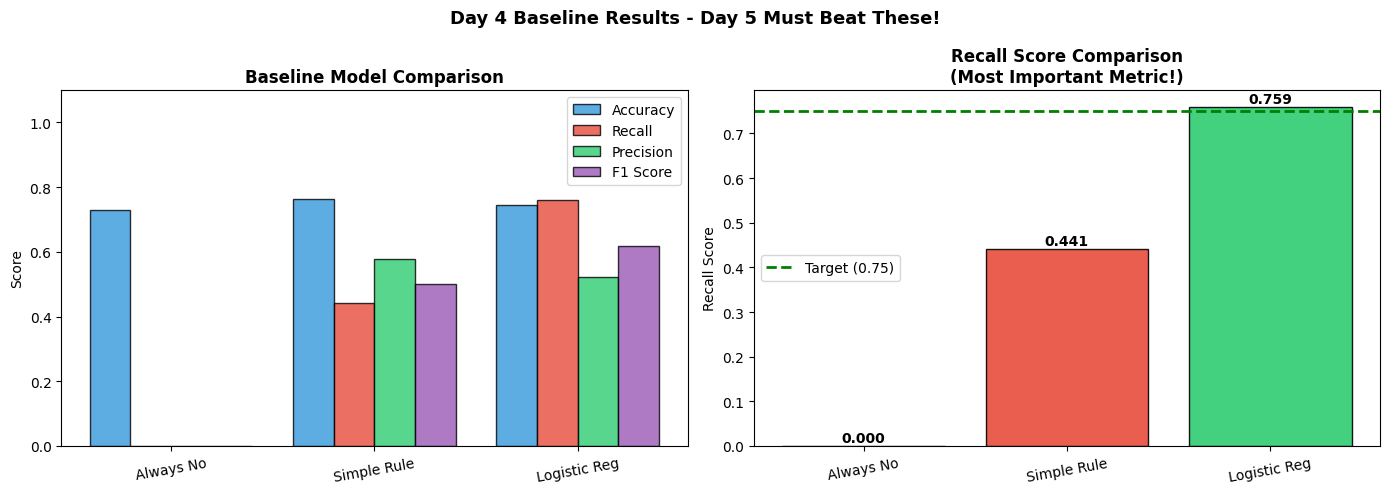

Chart saved to docs/baseline_comparison.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = results['Model'].tolist()
x = range(len(models))
width = 0.2

# Grouped bar chart
axes[0].bar([i - width*1.5 for i in x], results['Accuracy'], width,
            label='Accuracy', color='#3498db', alpha=0.8, edgecolor='black')
axes[0].bar([i - width*0.5 for i in x], results['Recall'], width,
            label='Recall', color='#e74c3c', alpha=0.8, edgecolor='black')
axes[0].bar([i + width*0.5 for i in x], results['Precision'], width,
            label='Precision', color='#2ecc71', alpha=0.8, edgecolor='black')
axes[0].bar([i + width*1.5 for i in x], results['F1'], width,
            label='F1 Score', color='#9b59b6', alpha=0.8, edgecolor='black')

axes[0].set_title('Baseline Model Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Always No', 'Simple Rule', 'Logistic Reg'],
                         rotation=10)
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Recall focused chart
recall_colors = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.7 else '#2ecc71'
                 for v in results['Recall']]
bars = axes[1].bar(models, results['Recall'],
                   color=recall_colors, edgecolor='black', alpha=0.9)
axes[1].set_title('Recall Score Comparison\n(Most Important Metric!)', fontweight='bold')
axes[1].set_ylabel('Recall Score')
axes[1].set_xticklabels(['Always No', 'Simple Rule', 'Logistic Reg'], rotation=10)
axes[1].axhline(y=0.75, color='green', linestyle='--', linewidth=2, label='Target (0.75)')
axes[1].legend()
for bar, val in zip(bars, results['Recall']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Day 4 Baseline Results - Day 5 Must Beat These!',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('docs/baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/baseline_comparison.png')

## CELL 13 - How to View MLflow UI
MLflow saves all your experiments automatically.
You can view them in a beautiful web dashboard.

In [14]:
print('=== HOW TO VIEW MLFLOW DASHBOARD ===')
print()
print('1. Open a NEW terminal window')
print('2. Navigate to your project folder')
print('3. Run this command:')
print()
print('   python -m mlflow ui')
print()
print('4. Open your browser')
print('5. Go to: http://localhost:5000')
print()
print('You will see:')
print('  - All 3 experiments listed')
print('  - All metrics in a table')
print('  - Charts comparing models')
print('  - Saved model files')
print()
print('This is what professional ML engineers use every day!')
print()
print('In Day 5 when you add Random Forest and XGBoost,')
print('you can compare ALL models in this dashboard!')

=== HOW TO VIEW MLFLOW DASHBOARD ===

1. Open a NEW terminal window
2. Navigate to your project folder
3. Run this command:

   python -m mlflow ui

4. Open your browser
5. Go to: http://localhost:5000

You will see:
  - All 3 experiments listed
  - All metrics in a table
  - Charts comparing models
  - Saved model files

This is what professional ML engineers use every day!

In Day 5 when you add Random Forest and XGBoost,
you can compare ALL models in this dashboard!


In [15]:
print('================================================')
print('DAY 4 COMPLETE!')
print('================================================')
print()
print('What you did today:')
print('  Loaded clean dataset from data/processed/')
print('  Separated features (X) and target (y)')
print('  Did proper time-based train/test split (80/20)')
print('  Understood all 5 evaluation metrics')
print('  Set up MLflow experiment tracking')
print('  Built 3 baseline models')
print('  Understood confusion matrix in detail')
print('  Saved benchmark scores for Day 5')
print()
print('Files created:')
print('  docs/confusion_matrix.png')
print('  docs/baseline_comparison.png')
print('  docs/baseline_scores.txt')
print('  mlruns/ folder (MLflow database)')
print()
print('BENCHMARK TO BEAT IN DAY 5:')
lr_recall = recall_score(y_test, lr_pred, zero_division=0)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)
print(f'  Recall > {lr_recall:.3f}')
print(f'  F1     > {lr_f1:.3f}')
print()
print('NEXT: Day 5 - Train Random Forest + XGBoost')
print('Those models will beat these baseline scores!')

DAY 4 COMPLETE!

What you did today:
  Loaded clean dataset from data/processed/
  Separated features (X) and target (y)
  Did proper time-based train/test split (80/20)
  Understood all 5 evaluation metrics
  Set up MLflow experiment tracking
  Built 3 baseline models
  Understood confusion matrix in detail
  Saved benchmark scores for Day 5

Files created:
  docs/confusion_matrix.png
  docs/baseline_comparison.png
  docs/baseline_scores.txt
  mlruns/ folder (MLflow database)

BENCHMARK TO BEAT IN DAY 5:
  Recall > 0.759
  F1     > 0.618

NEXT: Day 5 - Train Random Forest + XGBoost
Those models will beat these baseline scores!
